# Detect health of the plant

In [4]:
import torch
import torchvision
# Get regular imports 
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular.going_modular.engine import train_test_step
from going_modular.going_modular.data_import import get_data
import os
import pandas as pd

In [3]:
dataset_dir = "data/plant"

In [10]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


/tmp/ipykernel_275131/1573505709.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plant_df.plant, rotation=90)


Text(0.5, 1.0, 'Dataset balance')

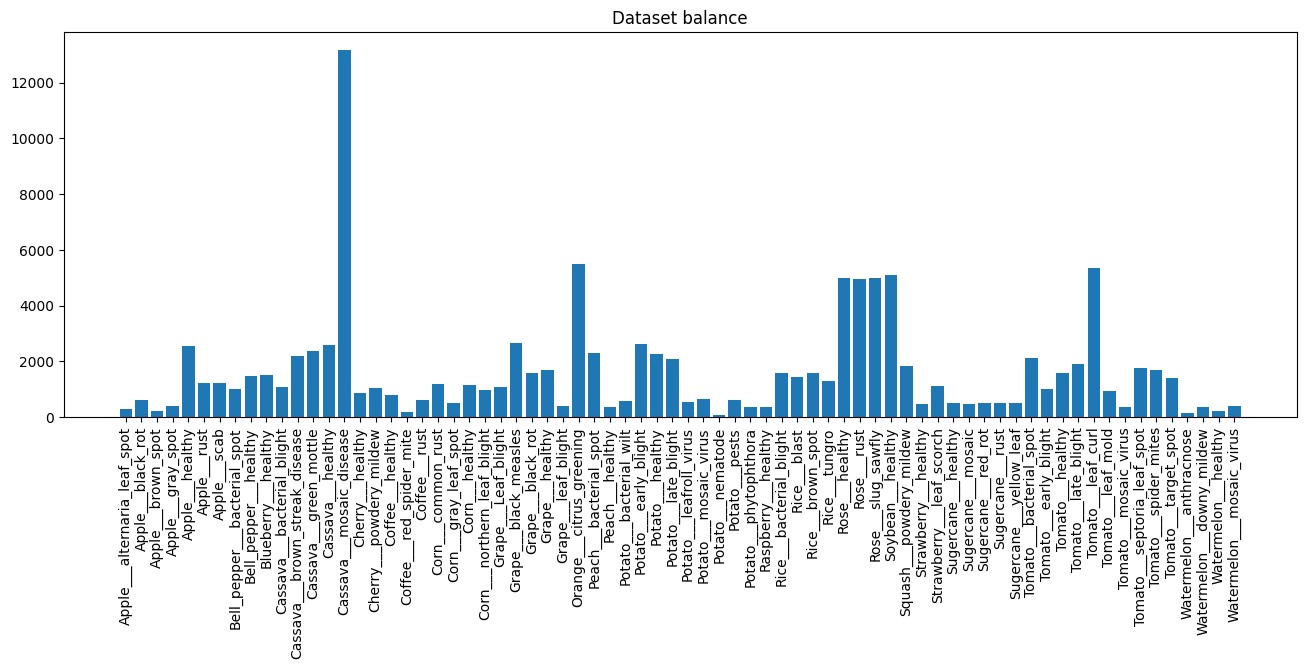

In [34]:
# Check if the dataset is balanced
plant_dict = {}
for dir in os.listdir(dataset_dir):
    plant_dict[dir] = len(os.listdir(os.path.join(dataset_dir, dir)))
plant_df = pd.DataFrame(plant_dict.items(), columns=["plant", "num"]).sort_values(by="plant")
fig = plt.figure(figsize=(35, 5))
ax = fig.add_subplot(1, 2, 1)
ax.bar(plant_df.plant, plant_df.num)
ax.set_xticklabels(plant_df.plant, rotation=90)
ax.set_title("Dataset balance")

In [35]:
plant_df

,plant,num
34,Apple___alternaria_leaf_spot,278
49,Apple___black_rot,621
40,Apple___brown_spot,215
14,Apple___gray_spot,395
38,Apple___healthy,2570
...,...,...
55,Tomato___target_spot,1404
54,Watermelon___anthracnose,155
16,Watermelon___downy_mildew,380
31,Watermelon___healthy,205


In [39]:
import torch
import torchvision
from torch import nn
from typing import Tuple

def create_vitb16_model(num_classes: int = 3,
                        seed: int = 42) -> Tuple[nn.Module, torchvision.transforms.Compose]:
    """
    Create a ViT-B/16 feature extractor model and transforms

    Args:
        num_classes (int, optional): number of classes. Defaults to 3.
        seed (int, optional): random seed. Defaults to 42.

    Returns:
        model (nn.Module): ViT-B/16 feature extractor model, 
        transforms (torchvision.transforms.Compose): ViT-B/16 images transforms
    """
    # Get the model weights
    weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
    # Get automatic transforms from pretrained ViT weights
    transforms = weights.transforms()
    # Get the model architecture with pretrained weights
    model = torchvision.models.vit_b_16(weights=weights)
    # Freeze the feature extractor
    for param in model.parameters():
        param.requires_grad = False
    # Get the last layer input
    for module in reversed(list(model.modules())):
        if isinstance(module, nn.Linear):
            in_features = module.in_features
            break     
    # Get its head
    torch.manual_seed(seed)
    model.heads = nn.Linear(in_features=in_features, out_features=num_classes)
    return model, transforms

In [ ]:
vit_b16_model, transforms = create_vitb16_model(num_classes=len(os.listdir(dataset_dir)))

In [43]:
import torchvision.transforms as T
train_transforms = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms
])

In [72]:
import importlib
import going_modular.going_modular.data_setup as data_setup
importlib.reload(data_setup)
from going_modular.going_modular.data_setup import create_dataloaders

In [73]:
train_dataloader, test_dataloader, class_names = create_dataloaders(transform=train_transforms,
                                                                    test_transform=transforms,
                                                                    train_dir=dataset_dir,
                                                                    split_size=0.8)

[INFO] Splitting dataset of length 116147 into splits of size: 92917 (80%), 23230 (19%)
Train data:
Test data:
Classes are not balanced, creating weights for each sample...


In [74]:
from going_modular.going_modular.engine import train_test_step

optimizer = torch.optim.Adam(vit_b16_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
history = train_test_step(model=vit_b16_model,
                          train_dataloader=train_dataloader,
                          test_dataloader=test_dataloader,
                          loss_fn=loss_fn,
                          optimizer=optimizer,
                          epochs=5,
                          device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
-------
Looked at 0/92917 samples
Looked at 12800/92917 samples
Looked at 25600/92917 samples
Looked at 38400/92917 samples
Looked at 51200/92917 samples
Looked at 64000/92917 samples
Looked at 76800/92917 samples
Looked at 89600/92917 samples
Train loss: 1.367 | Train accuracy: 82.00% | Max train probability: 69.74%
Test loss: 1.297 | Test accuracy: 84.40% | Max test probability: 74.65%
Epoch 1
-------
Looked at 0/92917 samples
Looked at 12800/92917 samples
Looked at 25600/92917 samples
Looked at 38400/92917 samples
Looked at 51200/92917 samples
Looked at 64000/92917 samples
Looked at 76800/92917 samples
Looked at 89600/92917 samples
Train loss: 1.240 | Train accuracy: 86.46% | Max train probability: 75.86%
Test loss: 1.265 | Test accuracy: 85.68% | Max test probability: 74.84%
Epoch 2
-------
Looked at 0/92917 samples
Looked at 12800/92917 samples
Looked at 25600/92917 samples
Looked at 38400/92917 samples
Looked at 51200/92917 samples
Looked at 64000/92917 samples
Looked at 

In [ ]:
from going_modular.going_modular.utils import save_model

save_model(model=vit_b16_model,
          target_dir="models",
          model_name="dectection_plant_health_vitb16.pth")

[INFO] Saving model to: models/dectection_plant_health_model.pth


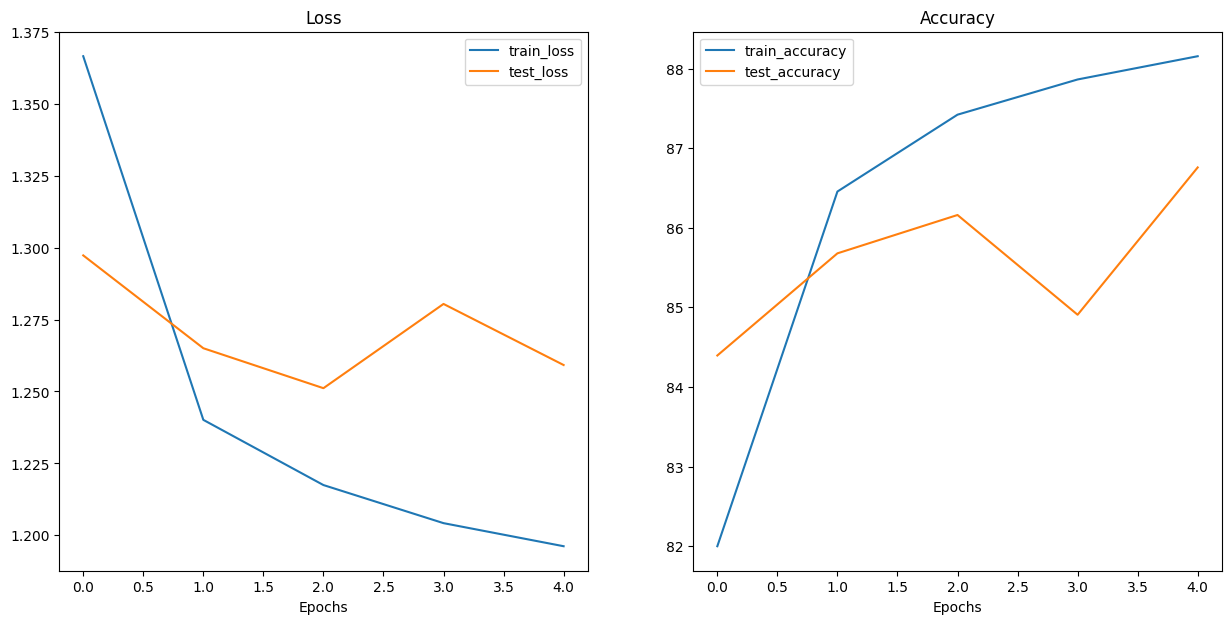

In [76]:
from going_modular.going_modular.utils import plot_loss_curves

plot_loss_curves(history)

In [5]:
import timm
import os
rexnet_150_model = timm.create_model("rexnet_150", pretrained = True, num_classes = len(os.listdir(dataset_dir))) 

In [ ]:
from timm.data import create_transform
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD


# Create the transform
transform = create_transform(
    input_size=rexnet_150_model.default_cfg["input_size"],
    mean=rexnet_150_model.default_cfg.get("mean", IMAGENET_DEFAULT_MEAN),
    std=rexnet_150_model.default_cfg.get("std", IMAGENET_DEFAULT_STD),
    crop_pct=rexnet_150_model.default_cfg.get("crop_pct", 1.0),
    interpolation=rexnet_150_model.default_cfg.get("interpolation", "bilinear")
)

print(transform)


Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


In [7]:
import importlib
import going_modular.going_modular.data_setup as data_setup
importlib.reload(data_setup)
from going_modular.going_modular.data_setup import create_dataloaders

In [9]:
train_dataloader, test_dataloader, class_names = create_dataloaders(transform=transform,
                                                                    train_dir=dataset_dir,
                                                                    split_size=0.8)

[INFO] Splitting dataset of length 116147 into splits of size: 92917 (80%), 23230 (19%)
Train data:
Test data:
Classes are not balanced, creating weights for each sample...


In [13]:
import torch
import torch.nn as nn
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [15]:
from going_modular.going_modular.engine import train_test_step

optimizer = torch.optim.Adam(rexnet_150_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
history = train_test_step(model=rexnet_150_model,
                          train_dataloader=train_dataloader,
                          test_dataloader=test_dataloader,
                          loss_fn=loss_fn,
                          optimizer=optimizer,
                          epochs=4,
                          device=device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 0
-------
Looked at 0/92917 samples
Looked at 12800/92917 samples
Looked at 25600/92917 samples
Looked at 38400/92917 samples
Looked at 51200/92917 samples
Looked at 64000/92917 samples
Looked at 76800/92917 samples
Looked at 89600/92917 samples
Train loss: 0.888 | Train accuracy: 95.80% | Max train probability: 85.05%
Test loss: 0.925 | Test accuracy: 93.37% | Max test probability: 84.57%
Epoch 1
-------
Looked at 0/92917 samples
Looked at 12800/92917 samples
Looked at 25600/92917 samples
Looked at 38400/92917 samples
Looked at 51200/92917 samples
Looked at 64000/92917 samples
Looked at 76800/92917 samples
Looked at 89600/92917 samples
Train loss: 0.873 | Train accuracy: 95.90% | Max train probability: 85.53%
Test loss: 0.911 | Test accuracy: 93.82% | Max test probability: 86.00%
Epoch 2
-------
Looked at 0/92917 samples
Looked at 12800/92917 samples
Looked at 25600/92917 samples
Looked at 38400/92917 samples
Looked at 51200/92917 samples
Looked at 64000/92917 samples
Looked at 

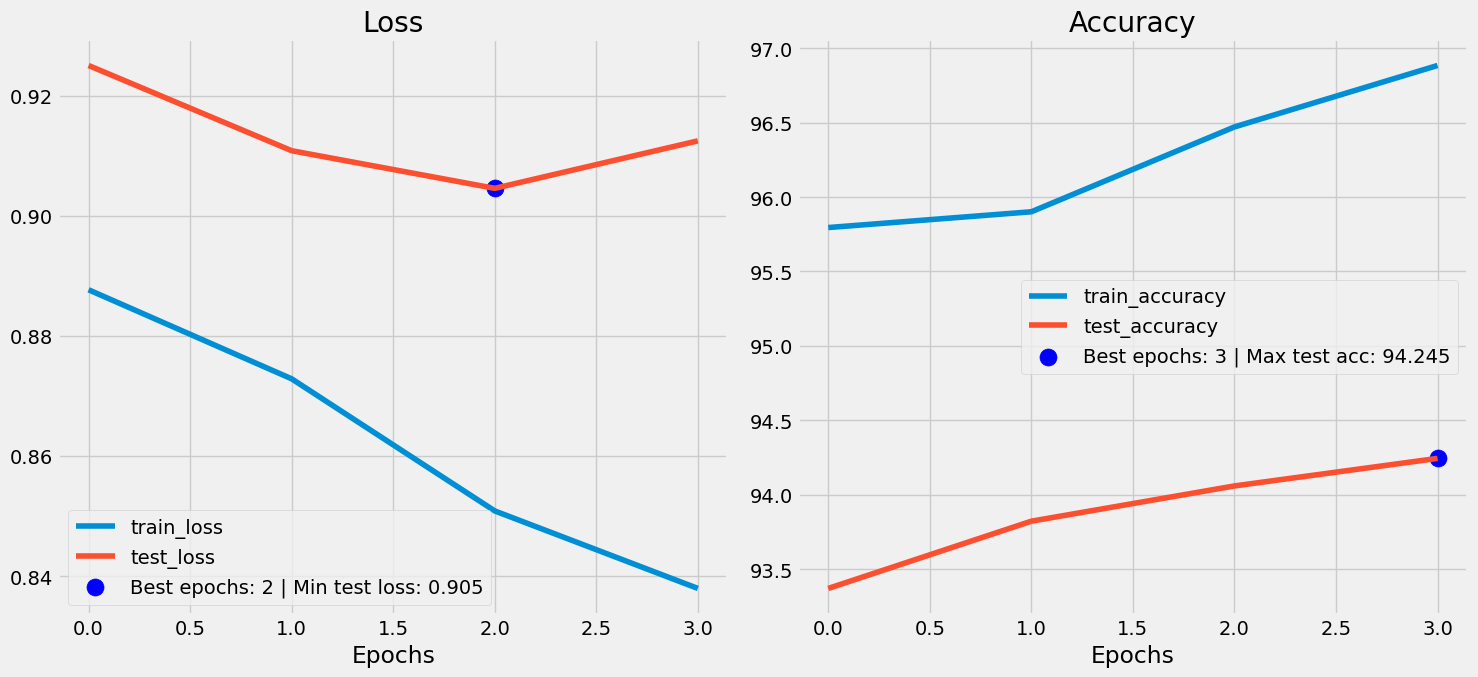

In [20]:
import going_modular.going_modular.utils as utils
importlib.reload(utils)
from going_modular.going_modular.utils import plot_loss_curves

plot_loss_curves(history)

In [ ]:
from going_modular.going_modular.utils import save_model
save_model(model=rexnet_150_model,
          target_dir="models",
          model_name="dectection_plant_health_rexnet150.pth")

[INFO] Saving model to: models/dectection_plant_health_rexnet.pth


In [31]:
importlib.reload(utils)

<module 'going_modular.going_modular.utils' from '/home/jojo/Bureau/Portfolio/Deep Learning/PyTorch/Classification/Computer vision/going_modular/going_modular/utils.py'>

In [5]:
import torch.nn as nn
import torchvision.models as models
import os

weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
efficientnet_b3_model = models.efficientnet_b3(weights=weights)
transforms = weights.transforms()
for param in efficientnet_b3_model.parameters():  
    param.requires_grad = False
in_features = efficientnet_b3_model.classifier[1].in_features
efficientnet_b3_model.classifier[1] = nn.Sequential(
    nn.BatchNorm1d(in_features, momentum=0.99, eps=0.001),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.45),
    nn.Linear(256, len(os.listdir(dataset_dir)))
)


In [8]:
from going_modular.going_modular.data_setup import create_dataloaders
train_dataloader, test_dataloader, class_names = create_dataloaders(transform=transforms,
                                                                    train_dir=dataset_dir,
                                                                    split_size=0.8)

[INFO] Splitting dataset of length 116147 into splits of size: 92917 (80%), 23230 (19%)
Train data:
Test data:
Classes are not balanced, creating weights for each sample...


In [11]:
optimizer = torch.optim.Adam(efficientnet_b3_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
history_efficientnet = train_test_step(model=efficientnet_b3_model,
                          train_dataloader=train_dataloader,
                          test_dataloader=test_dataloader,
                          loss_fn=loss_fn,
                          optimizer=optimizer,
                          epochs=1,
                          device=device)

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 0
-------
Looked at 0/92917 samples
Looked at 12800/92917 samples
Looked at 25600/92917 samples
Looked at 38400/92917 samples
Looked at 51200/92917 samples
Looked at 64000/92917 samples
Looked at 76800/92917 samples
Looked at 89600/92917 samples
Train loss: 1.607 | Train accuracy: 73.88% | Max train probability: 61.72%
Test loss: 3.036 | Test accuracy: 82.74% | Max test probability: 80.27%
Train time on cuda: 4.0 minutes 0.34961173299961956 secondes


In [15]:
from going_modular.going_modular.utils import load_model
import timm
efficientnet_b3_model = timm.create_model("rexnet_150", pretrained = True, num_classes = len(os.listdir(dataset_dir)))

efficientnet_b3_model =load_model("models/detection_plant_health_rexnet150.pth",
          model_builder=efficientnet_b3_model,
          device=device)
efficientnet_b3_model.eval()

RexNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (features): Sequential(
    (0): LinearBottleneck(
      (conv_dw): ConvNormAct(
        (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn): BatchNormAct2d(
          48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
      (act_dw): ReLU6()
      (conv_pwl): ConvNormAct(
        (conv): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNormAct2d(
          24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
    )
    (1): LinearBottlene

In [ ]:
from pathlib import Path
class_names = [d.name for d in Path(dataset_dir).iterdir() if d.is_dir()]
class_names = sorted([dir for dir in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, dir))])

In [26]:
with open("demos/plant_diseases/class_names.txt", "w") as f:
    f.write("\n".join(class_names))

In [27]:
import shutil
shutil.copy2("models/detection_plant_health_rexnet150.pth", "demos/plant_diseases/detection_plant_health_rexnet150.pth")

'demos/plant_diseases/detection_plant_health_rexnet150.pth'

In [38]:
import random
plant_diseases_example_path = Path("demos/plant_diseases/examples")
plant_diseases_example_path.mkdir(exist_ok=True, parents=True)
plant_img_path = list(Path(dataset_dir).glob("*/*.jpg"))
list_examples = [Path(filepath) for filepath in random.sample(plant_img_path, k=3)]
for example in list_examples:
    print(f"Copying {example} to {plant_diseases_example_path / example.name}")
    shutil.copy2(src=example, dst=plant_diseases_example_path / example.name)

Copying data/plant/Squash___powdery_mildew/75385.jpg to demos/plant_diseases/examples/75385.jpg
Copying data/plant/Orange___citrus_greening/60050.jpg to demos/plant_diseases/examples/60050.jpg
Copying data/plant/Cassava___mosaic_disease/26380.jpg to demos/plant_diseases/examples/26380.jpg


In [44]:
%%writefile demos/plant_diseases/app.py
### 1. Imports and class names setup ### 
import gradio as gr
import os
import torch
from timeit import default_timer as timer
from typing import Tuple, Dict
from timm.data import create_transform
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
import timm

# Setup class names
with open("class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

### 2. Model and transforms preparation ###

# Create the ViTB16 model
rexnet_150_model = timm.create_model("rexnet_150", 
                                     pretrained = True, 
                                     num_classes = len(class_names))

# Create the transform
rexnet_150_transforms = create_transform(input_size=rexnet_150_model.default_cfg["input_size"],
                                        mean=rexnet_150_model.default_cfg.get("mean", IMAGENET_DEFAULT_MEAN),
                                        std=rexnet_150_model.default_cfg.get("std", IMAGENET_DEFAULT_STD),
                                        crop_pct=rexnet_150_model.default_cfg.get("crop_pct", 1.0),
                                        interpolation=rexnet_150_model.default_cfg.get("interpolation", "bilinear")
                                    )

# Load saved weights
rexnet_150_model.load_state_dict(torch.load(f="detection_plant_health_rexnet150.pth",
                                            map_location=torch.device("cpu"),  # load to CPU
                                           )
                                            )

### 3. Predict function ###

# Create predict function
def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()
    
    # Transform the target image and add a batch dimension
    img = rexnet_150_transforms(img).unsqueeze(0)
    
    # Put model into evaluation mode and turn on inference mode
    rexnet_150_model.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(rexnet_150_model(img), dim=1)
    
    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)
    
    # Return the prediction dictionary and prediction time 
    return pred_labels_and_probs, pred_time

### 4. Gradio app ###

# Create title, description and article strings
title = "Plant Disease Detection 🪴🍀🍁"
description = "A Rexnet_150 feature extractor computer vision model to classify images of plant with diseases."
article = "Created at [detection plant health application](https://github.com/JoachimLombardi/Portfolio/blob/master/Deep%20Learning/PyTorch/Classification/Computer%20vision/detection_plant_health_application.ipynb)."

# Create examples list from "examples/" directory
example_list = [["examples/" + example] for example in os.listdir("examples")]

# Create the Gradio demo
demo = gr.Interface(fn=predict, # mapping function from input to output
                    inputs=gr.Image(type="pil"), # what are the inputs?
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"), # what are the outputs?
                             gr.Number(label="Prediction time (s)")], # our fn has two outputs, therefore we have two outputs
                    # Create examples list from "examples/" directory
                    examples=example_list, 
                    title=title,
                    description=description,
                    article=article)

# Launch the demo!
demo.launch()

Overwriting demos/plant_diseases/app.py
